In [1]:
!pip install pingouin statsmodels seaborn scipy pandas numpy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Set plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 2.7 MB/s eta 0:00:00


In [3]:
# ==============================================================================
# 1. LOAD EXCEL FILE
# ==============================================================================
import os

file_candidates = ['jasimresponse.xlsx']
file_path = None

for candidate in file_candidates:
    if os.path.exists(candidate):
        file_path = candidate
        break

if file_path is None:
    # Search working directory for any matching name
    all_files = [f for f in os.listdir('.') if 'jasimresponse' in f.lower()]
    if all_files:
        file_path = all_files[0]
    else:
        raise FileNotFoundError("Could not find 'jasimresponse.xlsx' in Google Colab. Please verify the uploaded file name.")

print(f"--> Successfully loaded file: {file_path}")
df = pd.read_excel(file_path)

--> Successfully loaded file: jasimresponse.xlsx


In [5]:
# ==============================================================================
# 2. SCREENING QUESTION FILTER (QUESTION B1)
# ==============================================================================
import re

def find_col(patterns, dataframe):
    """Helper function to find a column matching regex patterns."""
    for col in dataframe.columns:
        for p in patterns:
            if re.search(p, str(col), re.IGNORECASE):
                return col
    return None

# Find the B1 screening column
screening_col = find_col(['B1', 'screening', 'within the last 12 months', 'received risk'], df)

if screening_col:
    print(f"\nIdentified screening column: '{screening_col}'")

    # Check frequency of responses before filtering
    print("\nScreening Question Responses (B1):")
    print(df[screening_col].value_counts(dropna=False))

    initial_count = len(df)
    # Filter rows where the response indicates 'Yes'
    df = df[df[screening_col].astype(str).str.strip().str.lower().str.startswith('yes')].copy()
    filtered_count = len(df)
    excluded_count = initial_count - filtered_count

    print(f"\n--> Filter Applied: Retained {filtered_count} valid respondents who answered 'Yes'.")
    print(f"--> Excluded {excluded_count} respondents who answered 'No' or were blank.")
else:
    print("\nWarning: Could not automatically detect column B1. Proceeding with all rows.")
    df = df.copy()


Identified screening column: 'B1. Have you received risk-, safety-, security-, or crisis-related communication from any organization through a digital platform within the last 12 months?'

Screening Question Responses (B1):
B1. Have you received risk-, safety-, security-, or crisis-related communication from any organization through a digital platform within the last 12 months?
Yes    86
No     67
Name: count, dtype: int64

--> Filter Applied: Retained 86 valid respondents who answered 'Yes'.
--> Excluded 67 respondents who answered 'No' or were blank.


In [6]:
# ==============================================================================
# 3. COLUMN MAPPING & CONSTRUCT COMPUTATION
# ==============================================================================
gender_col = find_col(['gender', 'A1'], df)
age_col = find_col(['age', 'A2'], df)
edu_col = find_col(['education', 'qualification', 'A3'], df)
occ_col = find_col(['occupation', 'A4'], df)
income_col = find_col(['income', 'A5'], df)

# Mapping Likert scale items (1 to 6)
rce_cols = sorted([col for col in df.columns if re.search(r'RCE[1-6]', str(col), re.IGNORECASE)])
rt_cols  = sorted([col for col in df.columns if re.search(r'RT[1-6]', str(col), re.IGNORECASE)])
tr_cols  = sorted([col for col in df.columns if re.search(r'TR[1-6]', str(col), re.IGNORECASE)])
cc_cols  = sorted([col for col in df.columns if re.search(r'CC[1-6]', str(col), re.IGNORECASE)])

# Convert text Likert responses to numeric values (extracts leading digits if present)
all_likert_cols = rce_cols + rt_cols + tr_cols + cc_cols
for col in all_likert_cols:
    df[col] = df[col].astype(str).str.extract(r'(\d+)')[0].astype(float)

# Compute composite variables (Mean across items for each construct)
df['RCE_Mean'] = df[rce_cols].mean(axis=1)
df['RT_Mean']  = df[rt_cols].mean(axis=1)
df['TR_Mean']  = df[tr_cols].mean(axis=1)
df['CC_Mean']  = df[cc_cols].mean(axis=1)

# ==============================================================================
# SCALE RELIABILITY (CRONBACH'S ALPHA)
# ==============================================================================
print("\n" + "="*70)
print("SCALE RELIABILITY ANALYSIS (CRONBACH'S ALPHA)")
print("="*70)
scale_dict = {
    'Risk Communication Effectiveness (RCE)': rce_cols,
    'Response Timeliness (RT)': rt_cols,
    'Transparency (TR)': tr_cols,
    'Consumer Confidence (CC)': cc_cols
}

for scale_name, cols in scale_dict.items():
    alpha, _ = pg.cronbach_alpha(data=df[cols].dropna())
    print(f"{scale_name:42}: Cronbach's Alpha = {alpha:.3f}")


SCALE RELIABILITY ANALYSIS (CRONBACH'S ALPHA)
Risk Communication Effectiveness (RCE)    : Cronbach's Alpha = 0.931
Response Timeliness (RT)                  : Cronbach's Alpha = 0.922
Transparency (TR)                         : Cronbach's Alpha = 0.908
Consumer Confidence (CC)                  : Cronbach's Alpha = 0.933


In [7]:
# ==============================================================================
# OBJECTIVE 1: DEMOGRAPHIC PROFILE & DESCRIPTIVE STATISTICS
# ==============================================================================
print("\n" + "="*70)
print("OBJECTIVE 1: DEMOGRAPHIC PROFILE & STATUS OF STUDY VARIABLES")
print("="*70)

demo_mapping = {
    'Gender': gender_col,
    'Age': age_col,
    'Education': edu_col,
    'Occupation': occ_col,
    'Monthly Income': income_col
}

for label, col_name in demo_mapping.items():
    if col_name and col_name in df.columns:
        counts = df[col_name].value_counts(dropna=False)
        pcts = df[col_name].value_counts(normalize=True, dropna=False) * 100
        demo_table = pd.DataFrame({'Frequency': counts, 'Percentage (%)': pcts.round(2)})
        print(f"\n--- {label} Distribution ---")
        print(demo_table)

var_summary = pd.DataFrame({
    'Construct': ['Risk Communication Effectiveness', 'Response Timeliness', 'Transparency', 'Consumer Confidence'],
    'Mean': [df['RCE_Mean'].mean(), df['RT_Mean'].mean(), df['TR_Mean'].mean(), df['CC_Mean'].mean()],
    'Std Dev': [df['RCE_Mean'].std(), df['RT_Mean'].std(), df['TR_Mean'].std(), df['CC_Mean'].std()],
    'Min': [df['RCE_Mean'].min(), df['RT_Mean'].min(), df['TR_Mean'].min(), df['CC_Mean'].min()],
    'Max': [df['RCE_Mean'].max(), df['RT_Mean'].max(), df['TR_Mean'].max(), df['CC_Mean'].max()]
})
print("\n--- Descriptive Summary of Constructs (5-Point Likert Scale) ---")
print(var_summary.round(3).to_string(index=False))


OBJECTIVE 1: DEMOGRAPHIC PROFILE & STATUS OF STUDY VARIABLES

--- Gender Distribution ---
                   Frequency  Percentage (%)
A1. Gender                                  
Male                      56           65.12
Female                    28           32.56
Prefer not to say          1            1.16
Other                      1            1.16

--- Age Distribution ---
                Frequency  Percentage (%)
A2. Age                                  
Below 25 years         66           76.74
25 - 34 years          17           19.77
35 - 44 years           2            2.33
45 - 54 years           1            1.16

--- Education Distribution ---
                                     Frequency  Percentage (%)
A3. Educational Qualification                                 
Undergraduate                               38           44.19
Postgraduate                                29           33.72
Doctoral/Professional Qualification          9           10.47
Higher Seconda

In [9]:
# ==============================================================================
# OBJECTIVE 2: DEMOGRAPHIC DIFFERENCES IN CONSUMER CONFIDENCE
# ==============================================================================
print("\n" + "="*70)
print("OBJECTIVE 2: DIFFERENCES IN CONSUMER CONFIDENCE ACROSS DEMOGRAPHICS")
print("="*70)

# 1. Independent Sample t-test for Gender
if gender_col:
    male_group = df[df[gender_col].astype(str).str.strip().str.lower() == 'male']['CC_Mean'].dropna()
    female_group = df[df[gender_col].astype(str).str.strip().str.lower() == 'female']['CC_Mean'].dropna()

    if len(male_group) > 0 and len(female_group) > 0:
        t_stat, p_val = stats.ttest_ind(male_group, female_group)
        print("1. Gender Differences (Independent Samples t-test):")
        print(f"   Male   (n={len(male_group)}, Mean={male_group.mean():.2f}, SD={male_group.std():.2f})")
        print(f"   Female (n={len(female_group)}, Mean={female_group.mean():.2f}, SD={female_group.std():.2f})")
        print(f"   t-statistic = {t_stat:.3f}, p-value = {p_val:.4f}")
        print(f"   Inference: {'Statistically Significant' if p_val < 0.05 else 'No Statistically Significant Difference'}\n")

# 2. One-Way ANOVA across Age, Education, Occupation, Income
anova_factors = [('Age', age_col), ('Education', edu_col), ('Occupation', occ_col), ('Monthly Income', income_col)]
print("2. Multi-Group Demographics Differences (One-Way ANOVA):")
for label, col_name in anova_factors:
    if col_name and col_name in df.columns:
        cleaned_df = df[[col_name, 'CC_Mean']].dropna()
        # Keep groups with at least 2 entries for ANOVA
        valid_cats = cleaned_df[col_name].value_counts()[lambda x: x > 1].index
        cleaned_df = cleaned_df[cleaned_df[col_name].isin(valid_cats)]

        if len(valid_cats) > 1:
            aov = pg.anova(data=cleaned_df, dv='CC_Mean', between=col_name, detailed=True)
            f_val = aov['F'].iloc[0]
            p_val = aov['p_unc'].iloc[0]
            print(f"   - {label:15}: F = {f_val:.3f}, p-value = {p_val:.4f} -> {'Significant' if p_val < 0.05 else 'Not Significant'}")


OBJECTIVE 2: DIFFERENCES IN CONSUMER CONFIDENCE ACROSS DEMOGRAPHICS
1. Gender Differences (Independent Samples t-test):
   Male   (n=56, Mean=2.87, SD=1.11)
   Female (n=28, Mean=2.53, SD=0.99)
   t-statistic = 1.357, p-value = 0.1784
   Inference: No Statistically Significant Difference

2. Multi-Group Demographics Differences (One-Way ANOVA):
   - Age            : F = 0.467, p-value = 0.6287 -> Not Significant
   - Education      : F = 1.780, p-value = 0.1409 -> Not Significant
   - Occupation     : F = 0.060, p-value = 0.9807 -> Not Significant
   - Monthly Income : F = 1.552, p-value = 0.1951 -> Not Significant



OBJECTIVE 3: CORRELATION ANALYSIS (TESTING H1, H2, H3)
--- Pearson Correlation Matrix ---
                                  Risk Communication Effectiveness  \
Risk Communication Effectiveness                             1.000   
Response Timeliness                                          0.880   
Transparency                                                 0.825   
Consumer Confidence                                          0.795   

                                  Response Timeliness  Transparency  \
Risk Communication Effectiveness                0.880         0.825   
Response Timeliness                             1.000         0.819   
Transparency                                    0.819         1.000   
Consumer Confidence                             0.866         0.848   

                                  Consumer Confidence  
Risk Communication Effectiveness                0.795  
Response Timeliness                             0.866  
Transparency                      

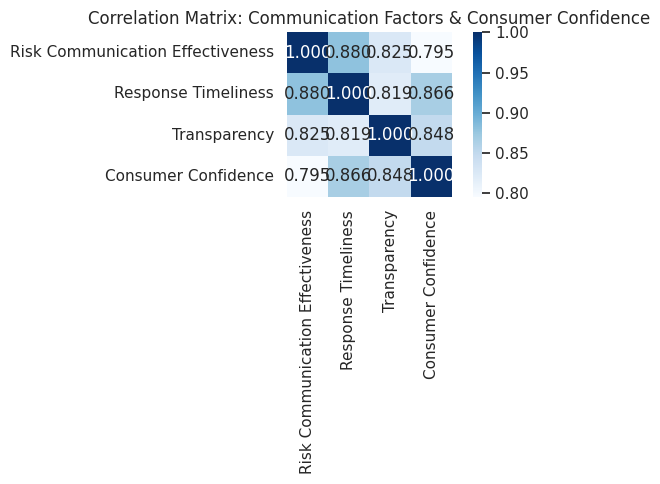


OBJECTIVE 4: MULTIPLE LINEAR REGRESSION ANALYSIS (TESTING H4)
                            OLS Regression Results                            
Dep. Variable:                CC_Mean   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     115.9
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           2.11e-29
Time:                        19:27:30   Log-Likelihood:                -56.338
No. Observations:                  86   AIC:                             120.7
Df Residuals:                      82   BIC:                             130.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

In [10]:
# ==============================================================================
# OBJECTIVE 3: RELATIONSHIP ANALYSIS (PEARSON CORRELATION - H1, H2, H3)
# ==============================================================================
print("\n" + "="*70)
print("OBJECTIVE 3: CORRELATION ANALYSIS (TESTING H1, H2, H3)")
print("="*70)

analysis_vars = {
    'RCE_Mean': 'Risk Communication Effectiveness',
    'RT_Mean': 'Response Timeliness',
    'TR_Mean': 'Transparency',
    'CC_Mean': 'Consumer Confidence'
}

corr_data = df[list(analysis_vars.keys())].dropna().rename(columns=analysis_vars)
corr_matrix = corr_data.corr()

print("--- Pearson Correlation Matrix ---")
print(corr_matrix.round(3))

hypotheses_corr = [
    ('H1: Communication Effectiveness -> Consumer Confidence', 'Risk Communication Effectiveness', 'Consumer Confidence'),
    ('H2: Response Timeliness -> Consumer Confidence', 'Response Timeliness', 'Consumer Confidence'),
    ('H3: Transparency -> Consumer Confidence', 'Transparency', 'Consumer Confidence')
]

print("\n--- Hypotheses H1-H3 Testing Summary ---")
for h_name, v1, v2 in hypotheses_corr:
    r, p = stats.pearsonr(corr_data[v1], corr_data[v2])
    status = "SUPPORTED" if p < 0.05 else "NOT SUPPORTED"
    print(f"{h_name}\n   -> r = {r:.3f}, p-value = {p:.4e} | Status: {status}\n")

# Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".3f", cbar=True, square=True)
plt.title("Correlation Matrix: Communication Factors & Consumer Confidence")
plt.tight_layout()
plt.show()

# ==============================================================================
# OBJECTIVE 4: EFFECT ASSESSMENT (MULTIPLE LINEAR REGRESSION - H4)
# ==============================================================================
print("\n" + "="*70)
print("OBJECTIVE 4: MULTIPLE LINEAR REGRESSION ANALYSIS (TESTING H4)")
print("="*70)

reg_df = df[['RCE_Mean', 'RT_Mean', 'TR_Mean', 'CC_Mean']].dropna()

X = reg_df[['RCE_Mean', 'RT_Mean', 'TR_Mean']]
X = sm.add_constant(X)
X.rename(columns={'RCE_Mean': 'Comm_Effectiveness', 'RT_Mean': 'Timeliness', 'TR_Mean': 'Transparency'}, inplace=True)
y = reg_df['CC_Mean']

model = sm.OLS(y, X).fit()
print(model.summary())

print("\n--- Hypothesis H4 Testing Summary ---")
print(f"Model Fit: R-squared = {model.rsquared:.3f}, Adjusted R-squared = {model.rsquared_adj:.3f}")
print(f"Overall Significance: F-statistic = {model.fvalue:.3f}, p-value = {model.f_pvalue:.4e}")

if model.f_pvalue < 0.05:
    print("Conclusion: H4 is SUPPORTED. Communication effectiveness, response timeliness, and transparency significantly influence consumer confidence.")
else:
    print("Conclusion: H4 is NOT SUPPORTED.")